# Visualize Toan Bo Truong Du Lieu Sau Tien Xu Ly
Notebook nay visualize tat ca truong trong `credit_risk_train.csv` (sau preprocessing).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 200)


In [20]:
train_path = 'credit_risk_train.csv'
test_path = 'credit_risk_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Khong su dung addr_state
train_df = train_df.drop(columns=['addr_state'], errors='ignore')
test_df = test_df.drop(columns=['addr_state'], errors='ignore')

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
print('num columns:', len(train_df.columns))
display(train_df.head())


train shape: (1021925, 22)
test shape : (255482, 22)
num columns: 22


,pub_rec,num_tl_90g_dpd_24m,annual_inc,dti,loan_amnt,tot_cur_bal,LTI,flag_high_dti,flag_very_high_dti,flag_any_derog,flag_recent_dpd,term_months,term_60,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_credit_card,purpose_debt_consolidation,purpose_home_improvement,verification_status_Source Verified,verification_status_Verified,label
0,1.0,0.0,11.082158,5.21,24700.0,12.383001,0.380000,0,0,1,0,36,0,False,False,False,False,True,False,False,True,0
1,0.0,0.0,11.396403,34.70,21600.0,12.896742,0.242697,0,0,0,0,60,1,False,False,False,True,False,False,False,False,1
2,0.0,0.0,11.082158,16.65,8625.0,10.583803,0.132692,0,0,0,0,36,0,False,False,True,False,True,False,True,False,1
3,0.0,0.0,10.771302,11.74,12000.0,10.842635,0.251926,0,0,0,0,60,1,False,False,True,False,True,False,False,False,0
4,0.0,0.0,11.018646,18.90,12000.0,10.500757,0.196721,0,0,0,0,36,0,False,False,True,True,False,False,True,False,0


In [21]:
schema = pd.DataFrame({
    'column': train_df.columns,
    'dtype': train_df.dtypes.astype(str).values,
    'missing_count': train_df.isna().sum().values,
    'missing_pct': (train_df.isna().mean() * 100).round(4).values,
    'n_unique': [train_df[c].nunique(dropna=True) for c in train_df.columns],
})
display(schema.sort_values(['dtype','column']).reset_index(drop=True))


,column,dtype,missing_count,missing_pct,n_unique
0,home_ownership_OTHER,bool,0,0.0,2
1,home_ownership_OWN,bool,0,0.0,2
2,home_ownership_RENT,bool,0,0.0,2
3,purpose_credit_card,bool,0,0.0,2
4,purpose_debt_consolidation,bool,0,0.0,2
5,purpose_home_improvement,bool,0,0.0,2
6,verification_status_Source Verified,bool,0,0.0,2
7,verification_status_Verified,bool,0,0.0,2
8,LTI,float64,0,0.0,130019
9,annual_inc,float64,0,0.0,53217


Label distribution (count):
label
0    815389
1    206536
Name: count, dtype: int64
Label distribution (ratio):
label
0    0.797895
1    0.202105
Name: count, dtype: float64


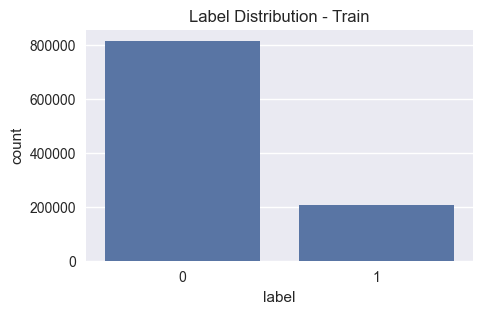

In [22]:
if 'label' in train_df.columns:
    vc = train_df['label'].value_counts().sort_index()
    print('Label distribution (count):')
    print(vc)
    print('Label distribution (ratio):')
    print((vc / vc.sum()).round(6))

    plt.figure(figsize=(5,3))
    sns.countplot(x='label', data=train_df)
    plt.title('Label Distribution - Train')
    plt.show()


In [23]:
num_cols = train_df.select_dtypes(include=[np.number, 'bool']).columns.tolist()
cat_cols = train_df.select_dtypes(include=['object','category']).columns.tolist()

print('numeric cols:', len(num_cols))
print('categorical cols:', len(cat_cols))
print('categorical list:', cat_cols)


numeric cols: 22
categorical cols: 0
categorical list: []


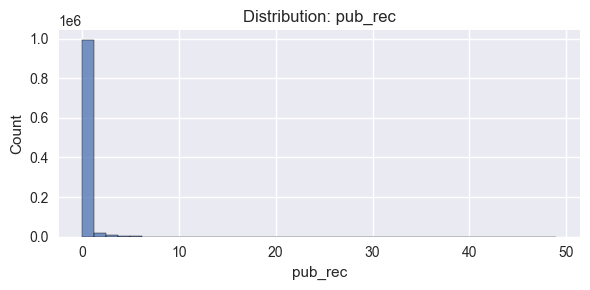

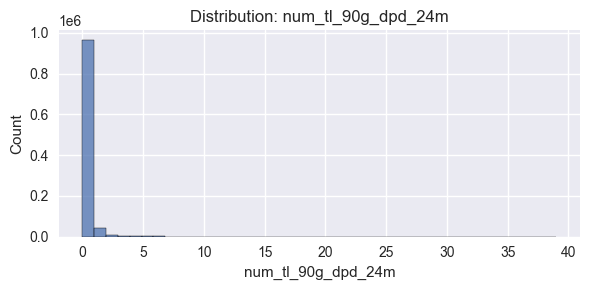

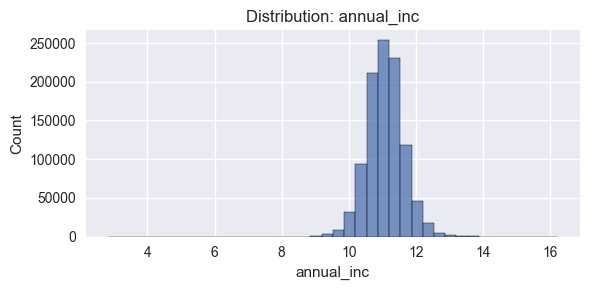

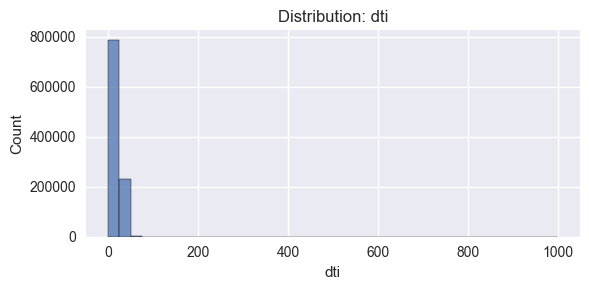

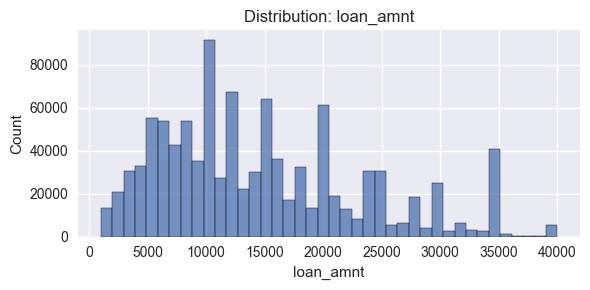

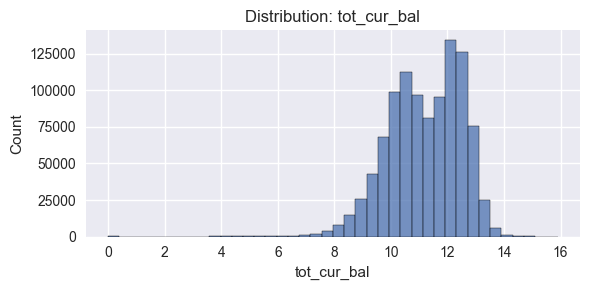

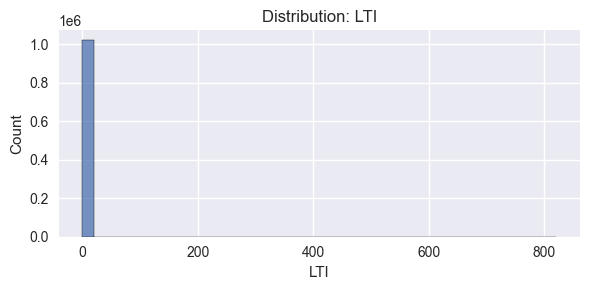

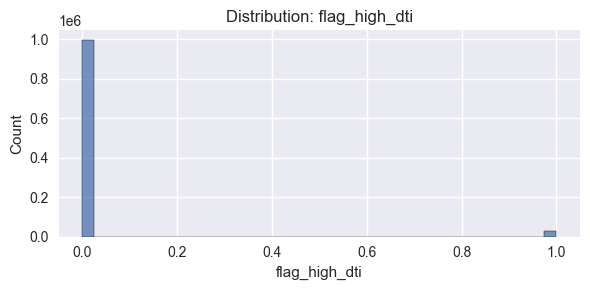

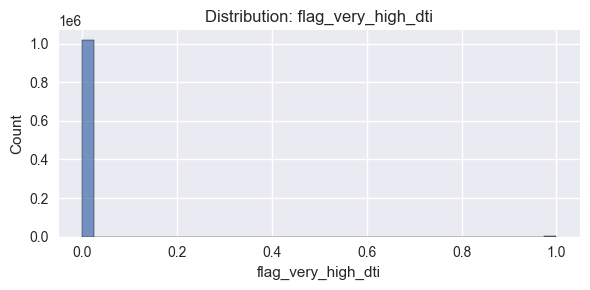

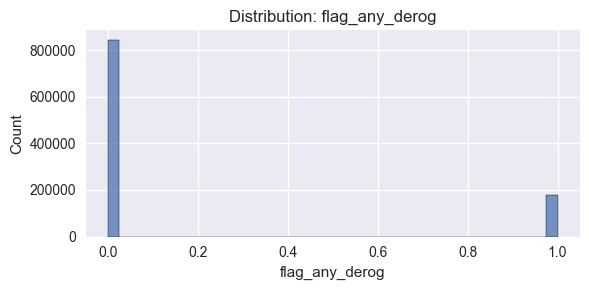

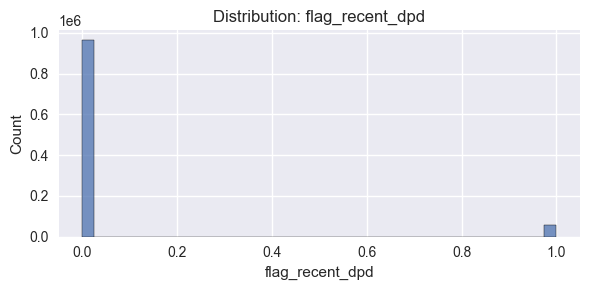

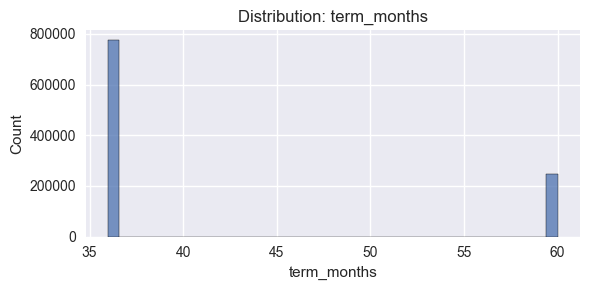

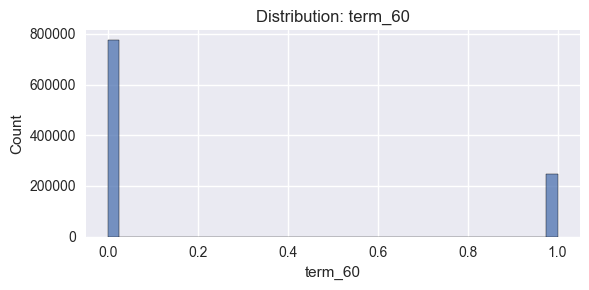

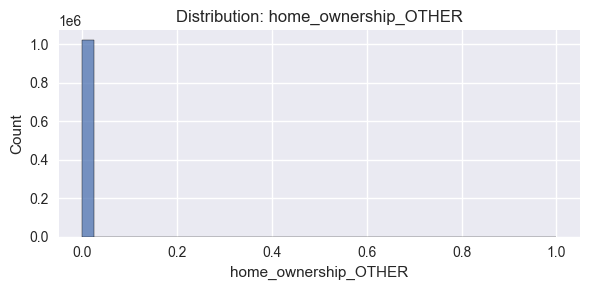

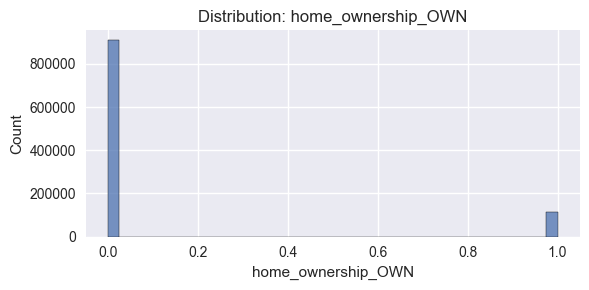

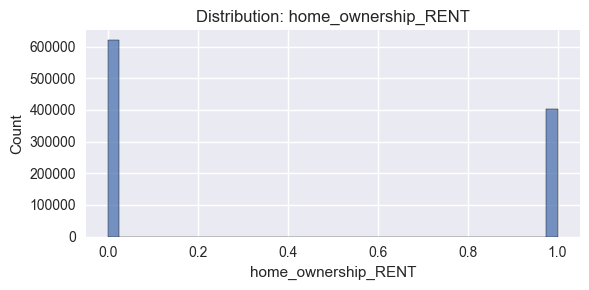

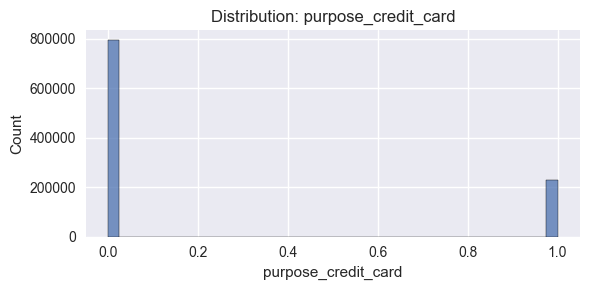

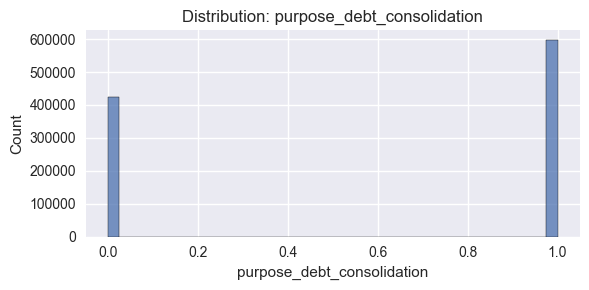

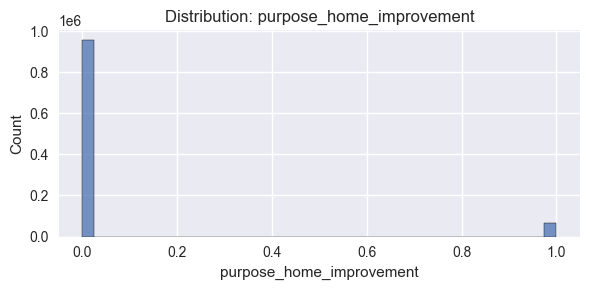

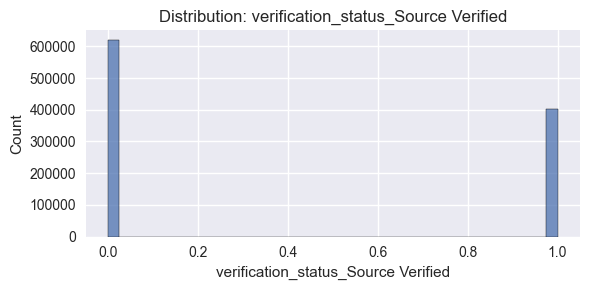

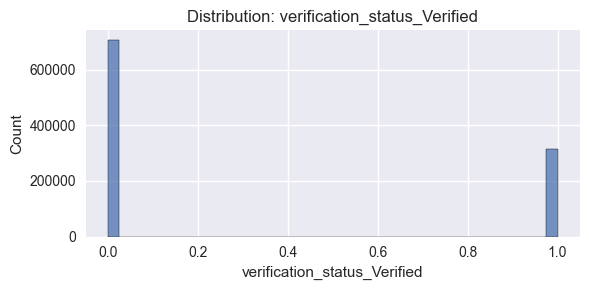

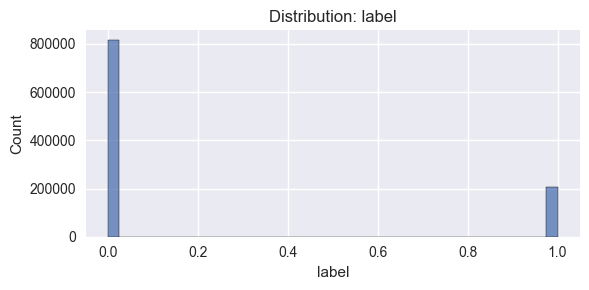

In [24]:
# Hist cho tung cot numeric
for col in num_cols:
    plt.figure(figsize=(6,3))
    series = pd.to_numeric(train_df[col], errors='coerce')
    sns.histplot(series.dropna(), bins=40, kde=False)
    plt.title(f'Distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


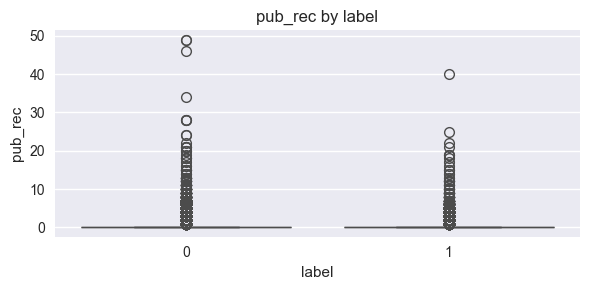

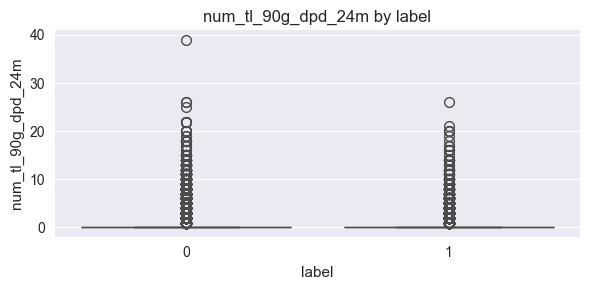

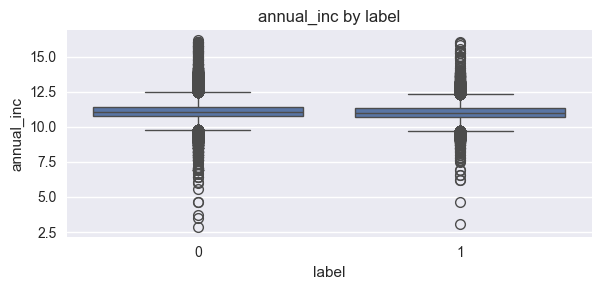

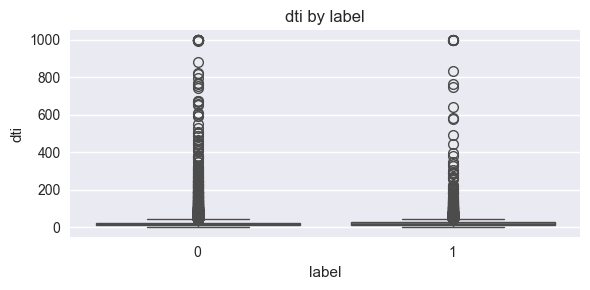

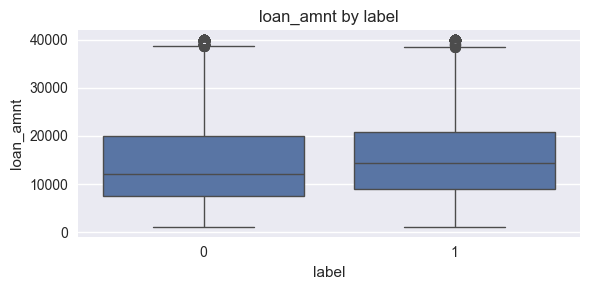

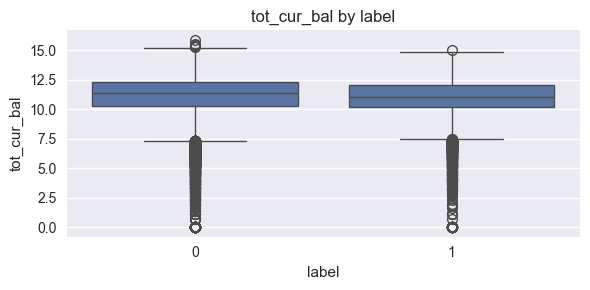

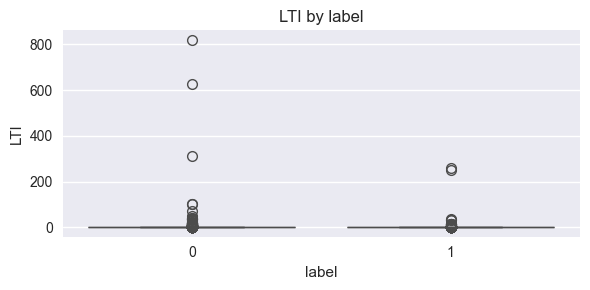

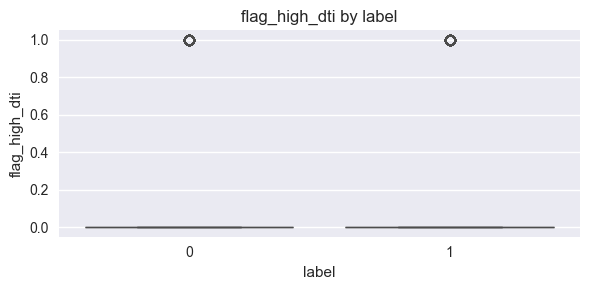

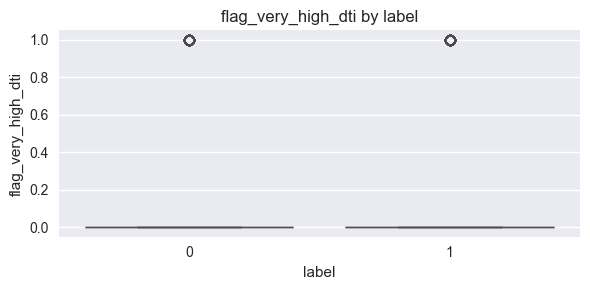

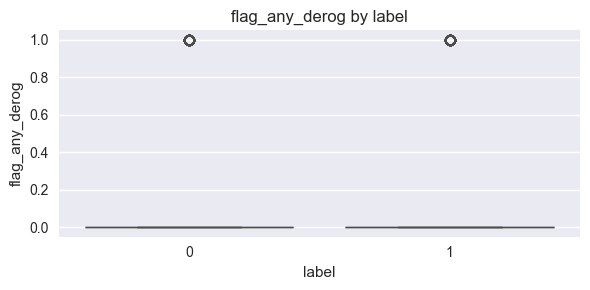

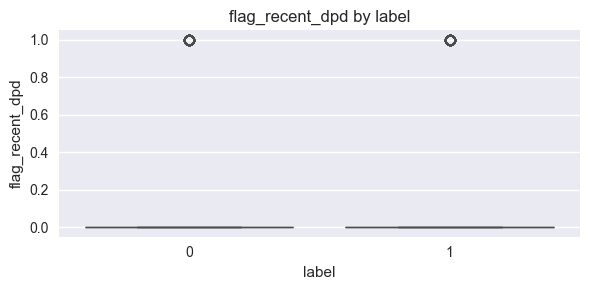

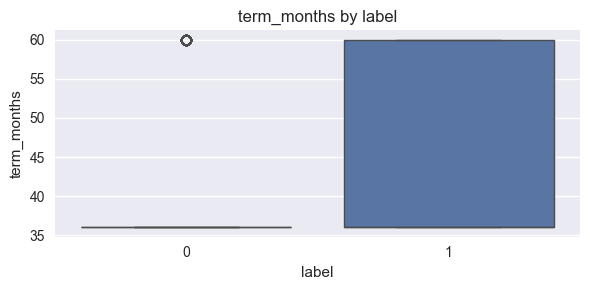

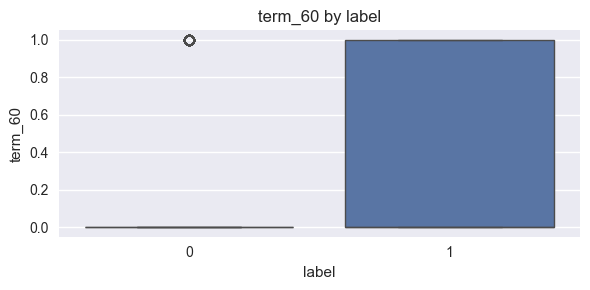

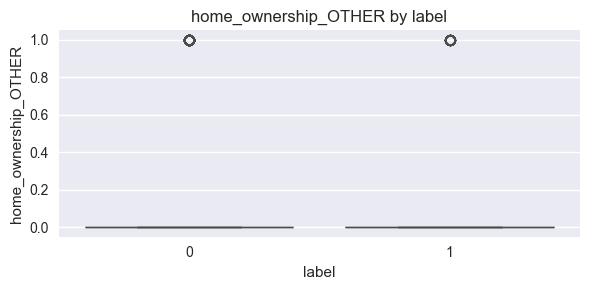

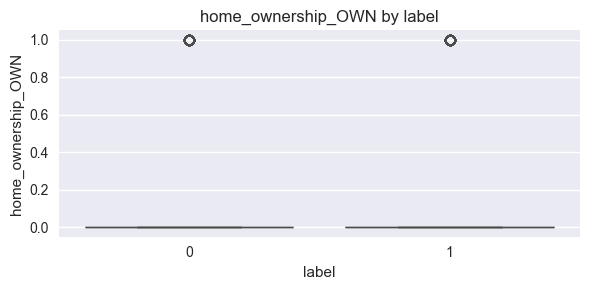

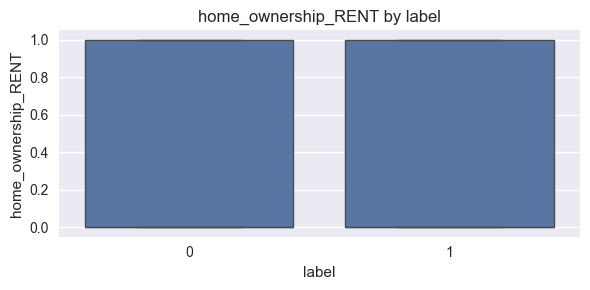

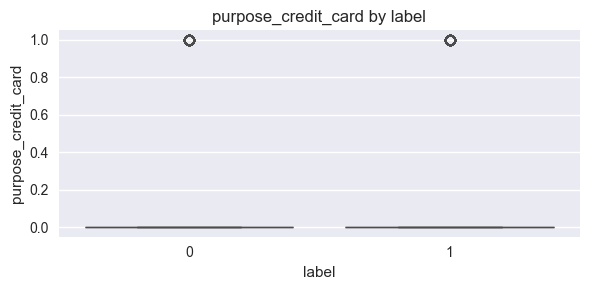

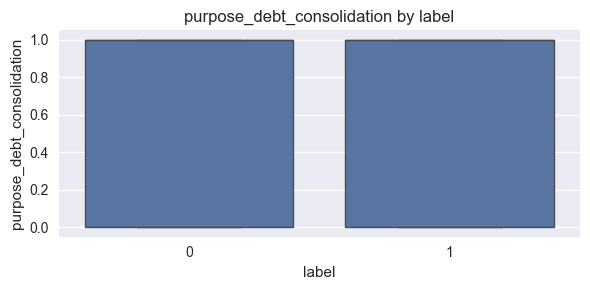

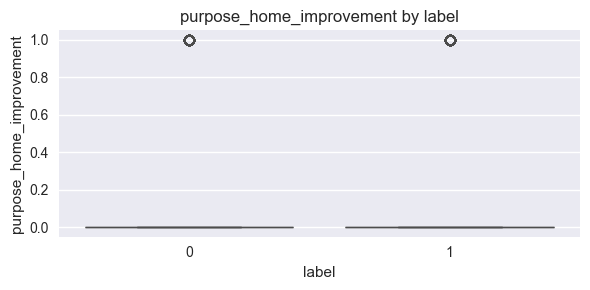

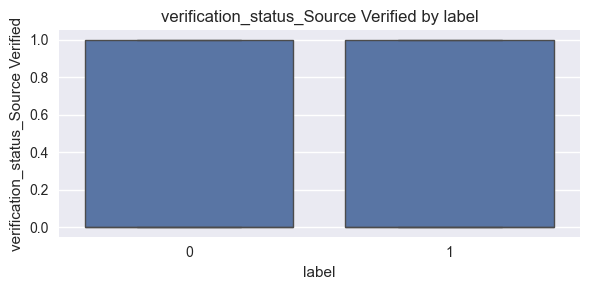

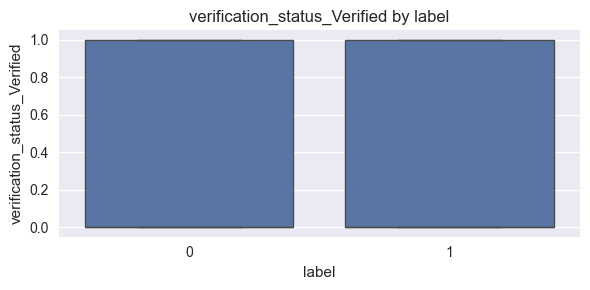

In [25]:
# Boxplot theo label cho tung cot numeric (neu co label)
if 'label' in train_df.columns:
    for col in num_cols:
        if col == 'label':
            continue
        plt.figure(figsize=(6,3))
        sns.boxplot(data=train_df[[col, 'label']].copy(), x='label', y=col)
        plt.title(f'{col} by label')
        plt.tight_layout()
        plt.show()


In [26]:
# Top category cho tung cot categorical
for col in cat_cols:
    vc = train_df[col].astype(str).value_counts(dropna=False).head(20)
    display(vc.to_frame(name='count'))

    plt.figure(figsize=(8,3))
    sns.barplot(x=vc.index, y=vc.values)
    plt.title(f'Top categories: {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


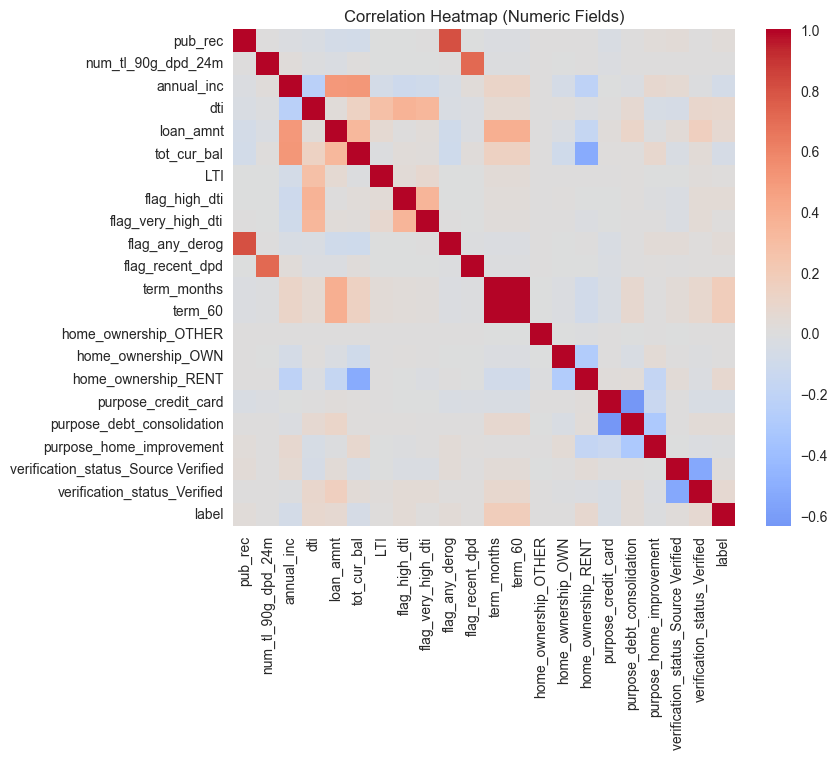

In [27]:
# Correlation heatmap cho numeric
if len(num_cols) > 1:
    corr = train_df[num_cols].apply(pd.to_numeric, errors='coerce').corr(numeric_only=True)
    plt.figure(figsize=(max(8, 0.4*len(corr.columns)), max(6, 0.35*len(corr.columns))))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
    plt.title('Correlation Heatmap (Numeric Fields)')
    plt.tight_layout()
    plt.show()
